In [1]:
import numpy as np
import pandas as pd
import glob
import os

In [2]:
import pandas as pd

def unify_tabular_data(oid, tabular):
    # 1. Trabajamos sobre una copia para no afectar el original
    df = tabular.copy()
    
    # 2. Lógica Vectorizada: Crear una columna 'key'
    # Por defecto la llave es el 'name'
    df['key'] = df['name']
    
    # Si 'fid' NO es None, la llave es 'name_fid'
    mask = ~df["fid"].isin([None])
    df.loc[mask, 'key'] = df.loc[mask, 'name'] + "_" + df.loc[mask, 'fid']
    
    # 3. Transponer: Convertir filas en columnas (Pivotar)
    # Tomamos la columna 'key' como índice y 'value' como valor, y giramos la tabla
    res = df.set_index('key')[['value']].T
    
    # 4. Asignamos el OID
    res.index = [oid]
    res.index.name = 'oid'
    res.columns.name = None 
    
    return res

In [3]:
path_feat = "../results_prod/objs_rand500000_2025-03-06_fromdb_ndetcleange8_ao_250306_features"
path_squid = "../results_prod/objs_rand500000_2025-03-06_fromdb_ndetcleange8_ao_250306_squidward"
path_mbappe = "../results_prod/objs_rand500000_2025-03-06_fromdb_ndetcleange8_ao_250306_mbappe"

In [4]:
path_chunks_feat = glob.glob(f'{path_feat}/*')
path_chunks_squid = glob.glob(f'{path_squid}/*')
path_chunks_mbappe = glob.glob(f'{path_mbappe}/*')
print(len(path_chunks_feat))
print(len(path_chunks_squid))
print(len(path_chunks_mbappe))

197
197
197


In [5]:
def extract_info(path_chunk):
    
    astro_objects_batch = pd.read_pickle("{}".format(path_chunk))

    df_features = []
    for i, astro_object in enumerate(astro_objects_batch):
        oid = astro_object['detections'].index[0]
        features_obj = astro_object['features']
        features_obj = unify_tabular_data(oid, features_obj)

        df_features.append(features_obj)

    df_features = pd.concat(df_features)

    return df_features

In [6]:
import multiprocessing
import tqdm

num_cores = 15

with multiprocessing.Pool(processes=num_cores) as pool:
    df_features = list(
        tqdm.tqdm(
            pool.imap_unordered(extract_info, path_chunks_feat),
            total=len(path_chunks_feat),
        )
    )

df_features = pd.concat(df_features)
df_features.index = df_features.index.str.replace('aid_', '')
df_features

100%|██████████| 197/197 [01:44<00:00,  1.89it/s]


,"g-r_mean_g,r","g-r_max_g,r","g-r_mean_corr_g,r","g-r_max_corr_g,r",W1-W2,W2-W3,W3-W4,g-W1,r-W1,g-W2,...,ulens_t0_r,ulens_mag0_r,"mean_distnr_g,r","sigma_distnr_g,r","mean_sharpnr_g,r","mean_chinr_g,r",Timespan,Coordinate_x,Coordinate_y,Coordinate_z
oid,,,,,,,,,,,,,,,,,,,,,
ZTF22aaodvwm,1.777674,1.894738,2.221123,2.115292,0.153,1.401,1.226,9.518198,7.297076,9.671198,...,296.809512,13.362364,0.262430,0.220876,-0.015654,0.692905,974.716258,0.562679,-0.293332,0.772883
ZTF22aaoewrv,0.710005,0.349000,0.523253,0.518430,-0.092,1.912,3.433,2.288917,1.765664,2.196917,...,697.996165,16.077000,0.508430,0.130934,-0.003333,0.619556,823.878805,0.294367,-0.550752,0.781038
ZTF22aaofoei,0.909933,0.317300,0.884698,0.515448,-0.089,1.170,3.485,3.676429,2.791730,3.587429,...,25.633035,15.937294,0.426056,0.170289,-0.015368,0.605105,960.741194,0.541854,-0.300829,0.784790
ZTF22aaodrxp,0.854042,0.573927,0.979902,0.972222,-0.063,1.056,3.579,3.963293,2.983391,3.900293,...,895.813597,16.718567,0.292183,0.155333,0.178086,3.503667,960.679295,0.601835,-0.402190,0.689955
ZTF22aaoglyo,0.655286,0.890730,0.961429,1.190359,1.173,2.523,2.346,6.810150,5.848721,7.983150,...,694.167005,20.137443,0.274819,0.148139,-0.007000,1.134000,1012.158576,-0.833768,-0.500016,-0.234127
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
ZTF19aaxisbw,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,...,363.883791,16.202468,0.543685,0.111710,-0.008000,0.229000,359.004580,0.364828,-0.820113,0.440811
ZTF19aaxirlj,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,...,355.810049,17.280533,0.254585,0.072884,-0.005000,0.600000,358.998655,0.342644,-0.869536,0.355672
ZTF19aaxipmo,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,...,355.468035,18.929594,0.101182,0.046342,-0.102000,1.536000,355.010364,0.381554,-0.849608,0.364118


In [7]:
df_probs_squid = []
for path_chunk_prob in path_chunks_squid:
    probs = pd.read_parquet(path_chunk_prob)
    df_probs_squid.append(probs)

df_probs_squid = pd.concat(df_probs_squid)
df_probs_squid

,class_name,probability,ranking,classifier_name,classifier_version
oid,,,,,
ZTF18adlrccy,RRLab,0.892400,1,lc_classifier_BHRF_forced_phot,2.1.0_bp
ZTF18adlrccy,RRLc,0.069840,2,lc_classifier_BHRF_forced_phot,2.1.0_bp
ZTF18adlrccy,CV/Nova,0.024528,3,lc_classifier_BHRF_forced_phot,2.1.0_bp
ZTF18adlrccy,CEP,0.007760,4,lc_classifier_BHRF_forced_phot,2.1.0_bp
ZTF18adlrccy,YSO,0.002184,5,lc_classifier_BHRF_forced_phot,2.1.0_bp
...,...,...,...,...,...
ZTF18aaltgfy,Microlensing,0.214000,2,lc_classifier_BHRF_forced_phot_stochastic,2.1.0_bp
ZTF18aaltgfy,Blazar,0.104000,3,lc_classifier_BHRF_forced_phot_stochastic,2.1.0_bp
ZTF18aaltgfy,AGN,0.080000,4,lc_classifier_BHRF_forced_phot_stochastic,2.1.0_bp


In [8]:
df_probs_mbappe = []
for path_chunk_prob in path_chunks_mbappe:
    probs = pd.read_parquet(path_chunk_prob)
    df_probs_mbappe.append(probs)

df_probs_mbappe = pd.concat(df_probs_mbappe)
df_probs_mbappe

,class_name,probability,ranking,classifier_name,classifier_version
oid,,,,,
ZTF18adlrayh,EB/EW,4.155799e-01,1,LC_classifier_ATAT_forced_phot(beta),1.1.0_bp
ZTF18adlrayh,DSCT,2.577148e-01,2,LC_classifier_ATAT_forced_phot(beta),1.1.0_bp
ZTF18adlrayh,RSCVn,1.069001e-01,3,LC_classifier_ATAT_forced_phot(beta),1.1.0_bp
ZTF18adlrayh,RRLc,9.882073e-02,4,LC_classifier_ATAT_forced_phot(beta),1.1.0_bp
ZTF18adlrayh,Periodic-Other,4.218155e-02,5,LC_classifier_ATAT_forced_phot(beta),1.1.0_bp
...,...,...,...,...,...
ZTF18aamljzy,Microlensing,2.123683e-09,17,LC_classifier_ATAT_forced_phot(beta),1.1.0_bp
ZTF18aamljzy,SNIIn,6.430682e-10,18,LC_classifier_ATAT_forced_phot(beta),1.1.0_bp
ZTF18aamljzy,SESN,1.957599e-10,19,LC_classifier_ATAT_forced_phot(beta),1.1.0_bp


In [9]:
bottom_squid_name = 'lc_classifier_BHRF_forced_phot'
bottom_mbappe_name = 'LC_classifier_ATAT_forced_phot(beta)'

In [10]:
prob_squid_wide_bottom = df_probs_squid[df_probs_squid.classifier_name == bottom_squid_name].pivot_table(
    index="oid",
    columns="class_name",
    values="probability"
)

prob_squid_wide_bottom

class_name,AGN,Blazar,CEP,CV/Nova,DSCT,EA,EB/EW,LPV,Microlensing,Periodic-Other,...,RRLab,RRLc,RSCVn,SESN,SLSN,SNII,SNIIn,SNIa,TDE,YSO
oid,,,,,,,,,,,,,,,,,,,,,
ZTF17aaaaaao,0.000840,0.003444,0.043516,0.014952,0.003784,0.191092,0.391644,0.001892,0.003276,0.107844,...,0.011352,0.157036,0.037840,0.001536,0.000912,0.001488,0.002736,0.001680,0.003648,0.019152
ZTF17aaaaabc,0.000740,0.002072,0.171832,0.020572,0.003656,0.122476,0.102368,0.016452,0.006660,0.021936,...,0.360116,0.096884,0.018280,0.001752,0.001896,0.002496,0.002808,0.001032,0.002016,0.043660
ZTF17aaaaabq,0.000640,0.001840,0.049504,0.022160,0.039984,0.081872,0.287504,0.000000,0.001760,0.163744,...,0.059024,0.218960,0.051408,0.001152,0.000944,0.001024,0.001680,0.001264,0.001936,0.013280
ZTF17aaaaabx,0.010560,0.067584,0.061200,0.225984,0.002700,0.233100,0.033300,0.022500,0.019008,0.037800,...,0.015300,0.009000,0.035100,0.002772,0.004356,0.001936,0.004884,0.003344,0.004708,0.196416
ZTF17aaaaacp,0.000532,0.002128,0.095800,0.010336,0.009580,0.093884,0.275904,0.003832,0.001900,0.068976,...,0.082388,0.252912,0.074724,0.000528,0.000336,0.000424,0.000896,0.000616,0.001200,0.022800
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
ZTF25aahzbdw,0.007268,0.018328,0.048240,0.046452,0.043416,0.069144,0.057888,0.020904,0.023068,0.123816,...,0.025728,0.027336,0.387528,0.003724,0.005320,0.005852,0.005928,0.008056,0.009120,0.055616
ZTF25aaiaefl,0.010920,0.016800,0.067268,0.136080,0.010040,0.088352,0.079316,0.007028,0.064680,0.081324,...,0.072288,0.028112,0.068272,0.021528,0.008736,0.013260,0.013104,0.011076,0.010296,0.180600
ZTF25aaievxs,0.130112,0.087312,0.001008,0.003424,0.002664,0.005184,0.002304,0.002016,0.000000,0.013176,...,0.001944,0.001872,0.005832,0.006912,0.022032,0.016416,0.025488,0.011664,0.025488,0.003424


In [11]:
prob_mbappe_wide_bottom = df_probs_mbappe[df_probs_mbappe.classifier_name == bottom_mbappe_name].pivot_table(
    index="oid",
    columns="class_name",
    values="probability"
)

prob_mbappe_wide_bottom

class_name,AGN,Blazar,CEP,CV/Nova,DSCT,EA,EB/EW,LPV,Microlensing,Periodic-Other,...,RRLab,RRLc,RSCVn,SESN,SLSN,SNII,SNIIn,SNIa,TDE,YSO
oid,,,,,,,,,,,,,,,,,,,,,
ZTF17aaaaaao,7.453441e-08,1.875062e-07,0.067890,0.000212,1.776044e-03,0.219777,0.508517,0.000060,2.108336e-11,0.033442,...,0.002545,0.121265,0.044172,3.780021e-12,4.936898e-13,3.075319e-08,1.644296e-11,3.754382e-08,1.462653e-12,0.000344
ZTF17aaaaabc,9.226933e-06,2.740641e-06,0.169752,0.002388,4.905498e-04,0.006661,0.024725,0.001019,2.447956e-11,0.000061,...,0.583126,0.134393,0.002777,6.515570e-13,7.060165e-15,7.187325e-09,2.664695e-17,1.044918e-06,1.905481e-11,0.074590
ZTF17aaaaabq,3.963724e-08,3.617333e-07,0.072487,0.000151,3.243719e-03,0.011810,0.279519,0.000002,6.269256e-13,0.063930,...,0.004097,0.358129,0.206540,2.524484e-12,1.246339e-13,7.759740e-09,7.863288e-12,1.109801e-09,2.197948e-11,0.000090
ZTF17aaaaabx,2.764866e-10,5.607761e-08,0.000885,0.000558,5.342907e-05,0.971867,0.022134,0.000026,3.294572e-10,0.000381,...,0.000474,0.000743,0.001356,2.243598e-15,6.188867e-16,4.554857e-10,2.309523e-14,5.931226e-08,2.580177e-10,0.001523
ZTF17aaaaacp,2.575148e-06,5.816602e-07,0.225437,0.000120,3.902570e-04,0.020607,0.129186,0.000373,4.616759e-09,0.011828,...,0.037388,0.506795,0.065592,4.983897e-12,2.095873e-11,3.066356e-07,2.144707e-11,9.293232e-07,1.414373e-09,0.002279
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
ZTF25aahzbdw,8.303169e-06,8.639148e-05,0.037775,0.024024,3.105662e-01,0.129948,0.122291,0.003201,1.350466e-09,0.012719,...,0.078529,0.047976,0.125719,2.451766e-06,1.208811e-11,2.002324e-04,3.696928e-07,4.047705e-05,4.725342e-07,0.106878
ZTF25aaiaefl,8.640304e-04,1.343670e-03,0.069418,0.145632,1.303601e-03,0.067179,0.077759,0.021023,1.721878e-08,0.046942,...,0.008992,0.009705,0.365341,4.912998e-07,4.397266e-10,1.350865e-06,1.381964e-08,7.226098e-04,1.210183e-08,0.172692
ZTF25aaievxs,1.307638e-01,2.957574e-02,0.000021,0.000634,3.775965e-06,0.000027,0.000082,0.000269,1.573724e-10,0.000661,...,0.000010,0.000089,0.002033,8.337587e-08,3.284822e-08,4.381152e-06,2.132210e-06,1.430232e-05,6.878761e-12,0.001022


In [12]:
df_features_coord = df_features[['Coordinate_x', 'Coordinate_y', 'Coordinate_z']]
df_features_coord

,Coordinate_x,Coordinate_y,Coordinate_z
oid,,,
ZTF22aaodvwm,0.562679,-0.293332,0.772883
ZTF22aaoewrv,0.294367,-0.550752,0.781038
ZTF22aaofoei,0.541854,-0.300829,0.784790
ZTF22aaodrxp,0.601835,-0.402190,0.689955
ZTF22aaoglyo,-0.833768,-0.500016,-0.234127
...,...,...,...
ZTF19aaxisbw,0.364828,-0.820113,0.440811
ZTF19aaxirlj,0.342644,-0.869536,0.355672
ZTF19aaxipmo,0.381554,-0.849608,0.364118


In [13]:
class_names = [
    "SNIa", "SESN", "SNII", "SNIIn", "SLSN", 
    "TDE", "Microlensing", "QSO", "AGN", "Blazar", 
    "YSO", "CV/Nova", "LPV", "EA", "EB/EW", 
    "Periodic-Other", "RSCVn", "CEP", "RRLab", "RRLc", "DSCT"
    ]

In [14]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import matplotlib.patheffects as pe
from astropy.coordinates import SkyCoord
import astropy.units as u
import math

# --- 1. PREPARACIÓN DE DATOS CORREGIDA ---
from astropy.coordinates import SkyCoord
import astropy.units as u


def plot_spatial_distribution(probs):
    # Unimos coordenadas con probabilidades
    df = df_features_coord.join(probs, how='inner')

    # INTERPRETACIÓN CORRECTA DE TUS COORDENADAS
    # Asumimos que x, y, z son Ecuatoriales (ICRS) porque es el estándar de ZTF/Alerce
    coords_icrs = SkyCoord(
        x=df['Coordinate_x'].values, 
        y=df['Coordinate_y'].values, 
        z=df['Coordinate_z'].values, 
        representation_type='cartesian',
        frame='icrs'  # Sistema Ecuatorial estándar
    )

    # Transformamos matemáticamente a Galácticas
    coords_galactic = coords_icrs.transform_to('galactic')

    # Ahora sí tenemos l y b reales
    df['l'] = coords_galactic.l.deg
    df['b'] = coords_galactic.b.deg

    # Determinar la clase predicha
    df['predicted_class'] = df[class_names].idxmax(axis=1)

    # --- 2. CONFIGURACIÓN DEL GRÁFICO ---

    # Calculamos el tamaño del grid
    # Queremos 1 gráfico general + N clases
    total_plots = 1 + len(class_names)
    ncols = 3  # Puedes cambiar esto a 2 o 4 según prefieras
    nrows = math.ceil(total_plots / ncols)

    fig, axes = plt.subplots(nrows, ncols, figsize=(25, 5*nrows), sharex=False, sharey=False)
    axes = axes.flatten()

    # --- 3. CURVA ECLÍPTICA ---
    def get_ecliptic_curve():
        l_ecl = np.linspace(0, 360, 360)
        coords = SkyCoord(lon=l_ecl*u.deg, lat=0*u.deg, frame='barycentrictrueecliptic')
        gal = coords.transform_to('galactic')
        sort_idx = np.argsort(gal.l.deg)
        return gal.l.deg[sort_idx], gal.b.deg[sort_idx]

    ecl_l, ecl_b = get_ecliptic_curve()

    # --- 4. GENERACIÓN DE LOS PLOTS ---

    # Lista de títulos a iterar: Primero 'All Data', luego cada clase
    plot_list = ['All Data'] + class_names

    for i, ax in enumerate(axes):
        if i >= len(plot_list):
            ax.axis('off') # Apagar subplots vacíos
            continue

        current_class = plot_list[i]
        
        # Filtrar datos
        if current_class == 'All Data':
            subset = df # Todos los datos
        else:
            # Solo filas donde la clase ganadora es la actual
            subset = df[df['predicted_class'] == current_class]

        # Graficar si hay datos
        if len(subset) > 0:
            h = ax.hist2d(subset['l'], subset['b'], bins=[180, 90], range=[[0, 360], [-90, 90]], 
                        cmap='viridis', cmin=1)
            plt.colorbar(h[3], ax=ax, fraction=0.046, pad=0.04)
        
        # Dibujar Eclíptica
        ax.plot(ecl_l, ecl_b, 'y-', linewidth=2, 
                path_effects=[pe.withStroke(linewidth=4, foreground="black")], 
                label='Ecliptic')

        # Estética
        ax.set_title(current_class, fontsize=14, fontweight='bold')
        ax.set_xlim(0, 360)
        ax.set_ylim(-90, 90)
        ax.grid(True, linestyle=':', alpha=0.4)
        
        # Labels solo en bordes (opcional, para limpieza)
        if i % ncols == 0:
            ax.set_ylabel("Galactic Latitude (b)")
        if i >= total_plots - ncols:
            ax.set_xlabel("Galactic Longitude (l)")

    plt.tight_layout()
    plt.show()

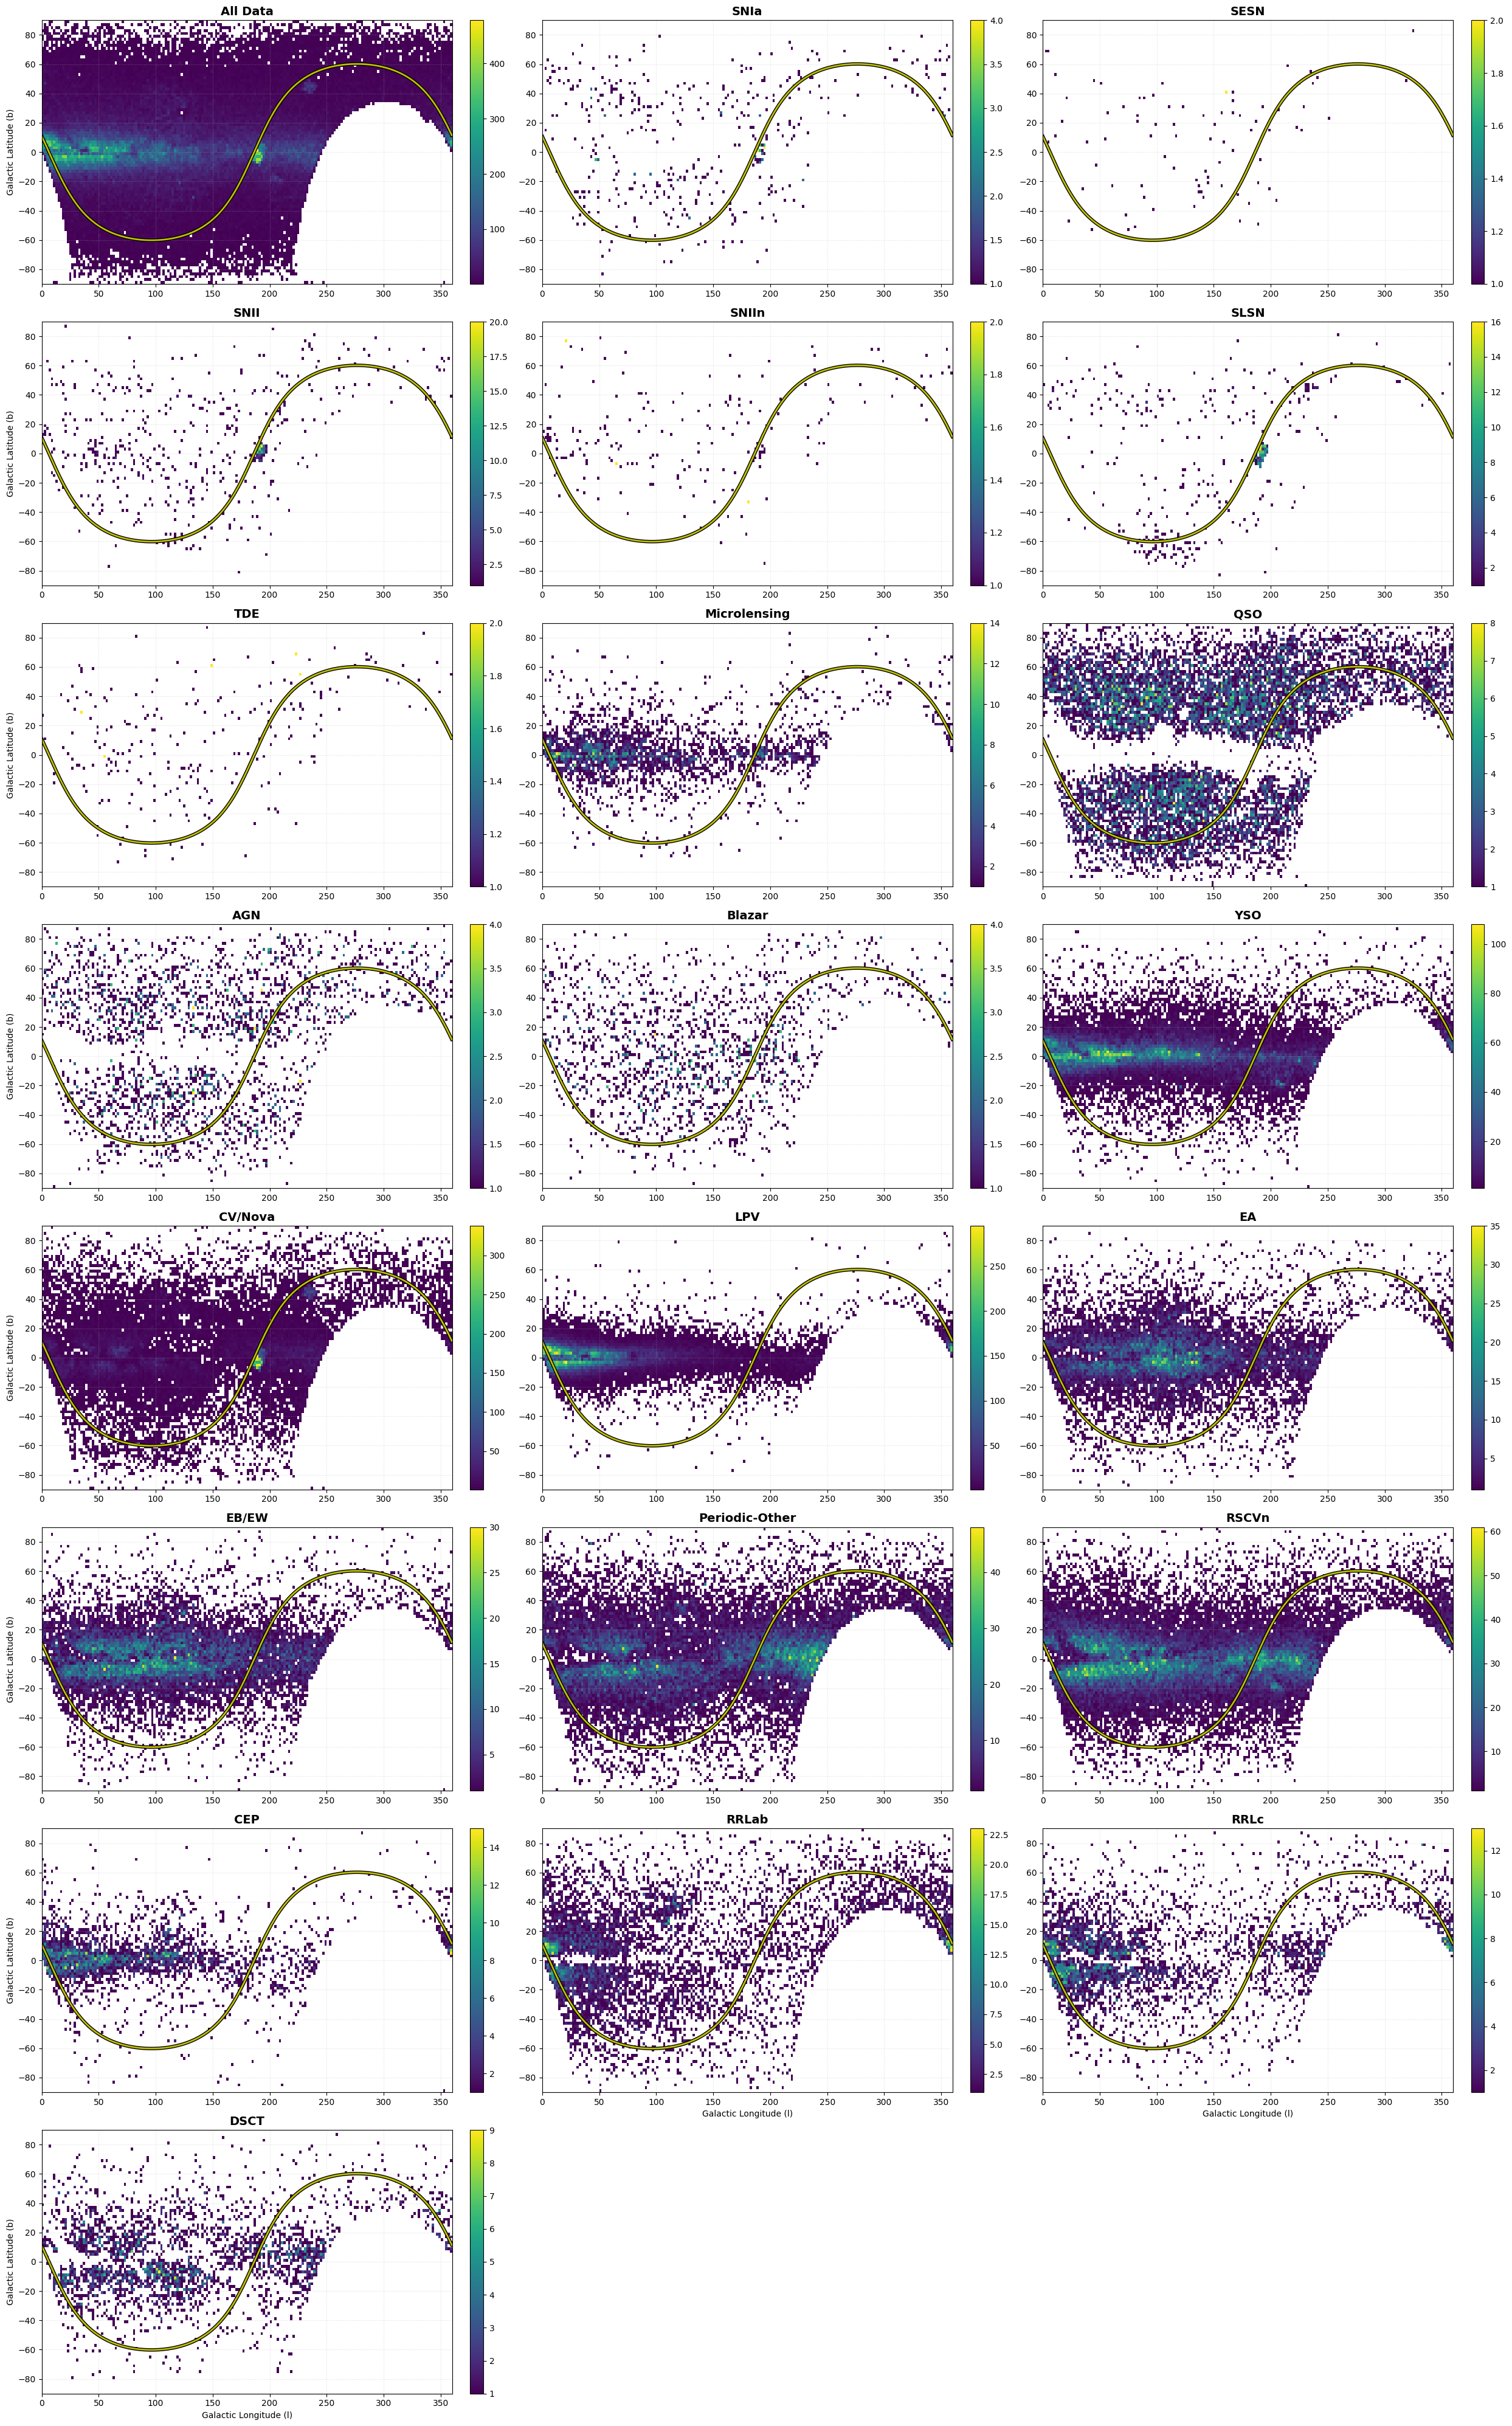

In [15]:
plot_spatial_distribution(prob_squid_wide_bottom)

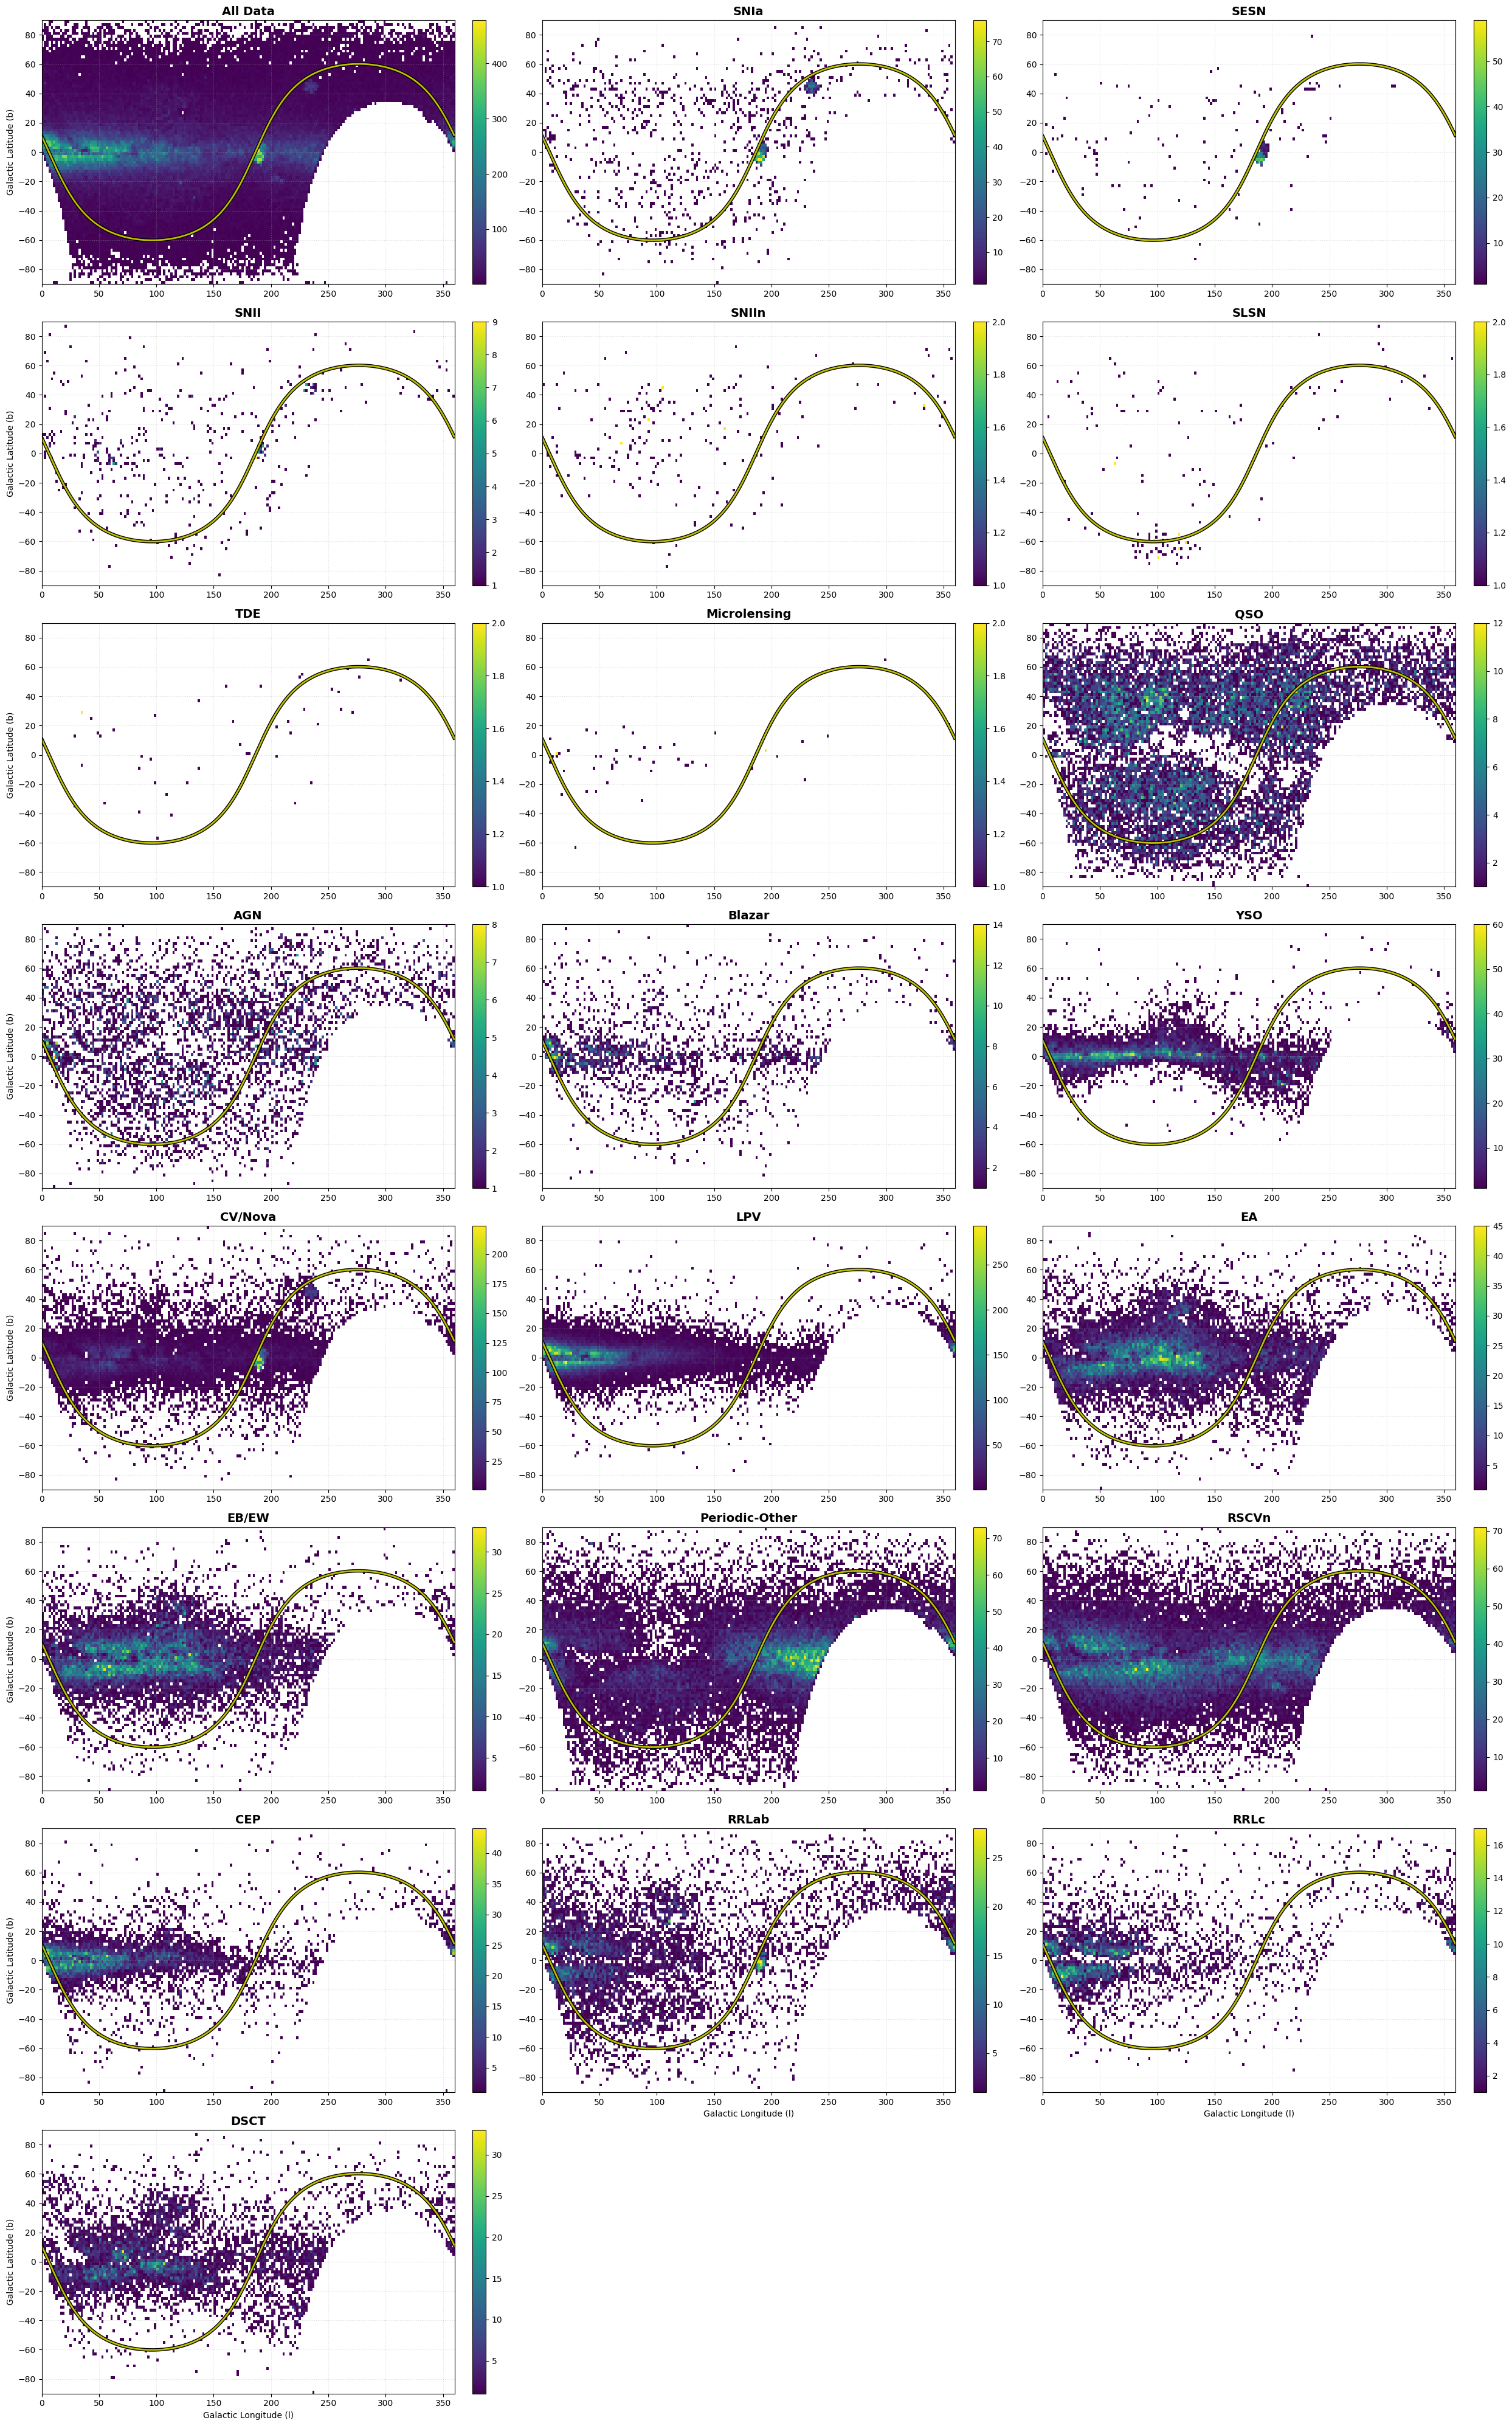

In [16]:
plot_spatial_distribution(prob_mbappe_wide_bottom)

In [17]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import scipy.ndimage
from astropy.coordinates import SkyCoord

# --- 1. DEFINICIÓN DE CLASES ---
extragalactic_classes = [
    "SNIa", "SESN", "SNII", "SNIIn", "SLSN", 
    "TDE", "QSO", "AGN", "Blazar"
]

galactic_classes = [
    "YSO", "CV/Nova", "LPV", "EA", "EB/EW", 
    "Periodic-Other", "RSCVn", "CEP", "RRLab", "RRLc", "DSCT", 
    "Microlensing" 
]

# --- 2. PREPARACIÓN DE DATOS ---
def prepare_data(df_features, df_probs):
    # Unir features con probabilidades
    # Usamos intersection de índices para asegurar que coincidan
    df = df_features.join(df_probs, how='inner')
    
    # --- Coordenadas ---
    # Convertir Cartesianas (x,y,z) a Galácticas (l,b)
    c = SkyCoord(x=df['Coordinate_x'].values, 
                 y=df['Coordinate_y'].values, 
                 z=df['Coordinate_z'].values, 
                 representation_type='cartesian', frame='icrs')
    gal = c.galactic
    df['l'] = gal.l.deg
    df['b'] = gal.b.deg
    
    # --- Predicción ---
    # Asumimos que df_probs tiene las columnas de las clases
    class_cols = df_probs.columns
    df['predicted_class'] = df[class_cols].idxmax(axis=1)
    df['max_prob'] = df[class_cols].max(axis=1)
    
    # --- Color (g-r) ---
    # ACTUALIZACIÓN: Usamos los nombres de tus columnas nuevas
    if 'g-r_mean_corr_g,r' in df.columns:
        # Prioridad 1: Color medio corregido por extinción
        df['color_gr'] = df['g-r_mean_corr_g,r']
    elif 'g-r_mean_g,r' in df.columns:
        # Prioridad 2: Color medio observado
        df['color_gr'] = df['g-r_mean_g,r']
    else:
        # Fallback: Calcularlo manualmente con las medias
        df['color_gr'] = df['Mean_g'] - df['Mean_r']
        
    return df

# --- 3. FUNCIÓN DE CONTORNOS ---
def plot_density_contours(x, y, ax, bins=50, levels=6, color='red'):
    """Dibuja contornos de densidad suavizados (estilo mapa topográfico)"""
    mask = np.isfinite(x) & np.isfinite(y)
    x_clean = x[mask]
    y_clean = y[mask]
    
    if len(x_clean) < 10: return 

    # Histograma 2D
    H, xedges, yedges = np.histogram2d(x_clean, y_clean, bins=bins)
    
    # Suavizado para que las curvas se vean orgánicas
    H_smooth = scipy.ndimage.gaussian_filter(H, sigma=1.5)
    
    xcenters = (xedges[:-1] + xedges[1:]) / 2
    ycenters = (yedges[:-1] + yedges[1:]) / 2
    
    # Dibujar
    ax.contour(xcenters, ycenters, H_smooth.T, levels=levels, 
               colors=color, linewidths=1.2, alpha=0.9)

# --- 4. GRAFICAR FIGURA 17 ---
def plot_figure_17_updated(df):
    # Filtrar subconjuntos
    df_gal = df[df['predicted_class'].isin(galactic_classes)]
    df_ext = df[df['predicted_class'].isin(extragalactic_classes)]
    
    # Crear figura (1 fila, 2 columnas, comparten eje Y de latitud)
    fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(18, 8), sharey=True)
    
    cmap = 'viridis' 
    point_size = 2   
    # Ajusta vmin/vmax a la realidad de tus probabilidades (ej. 0.3 a 0.9)
    vmin, vmax = 0.2, 0.8 
    
    # --- PANEL IZQUIERDO: GALACTIC (l vs b) ---
    if not df_gal.empty:
        sc1 = ax1.scatter(df_gal['l'], df_gal['b'], c=df_gal['max_prob'], 
                          s=point_size, cmap=cmap, vmin=vmin, vmax=vmax, rasterized=True)
        plot_density_contours(df_gal['l'], df_gal['b'], ax1, bins=[60, 40])
    
    ax1.set_xlim(0, 360)
    ax1.set_ylim(-90, 90)
    ax1.set_xlabel("Galactic longitude (gal l) [deg]", fontsize=14)
    ax1.set_ylabel("Galactic latitude (gal b) [deg]", fontsize=14)
    ax1.set_title("Galactic Candidates", fontsize=14, fontweight='bold')
    ax1.grid(True, linestyle=':', alpha=0.3)

    # --- PANEL DERECHO: EXTRAGALACTIC (g-r vs b) ---
    if not df_ext.empty:
        sc2 = ax2.scatter(df_ext['color_gr'], df_ext['b'], c=df_ext['max_prob'], 
                          s=point_size, cmap=cmap, vmin=vmin, vmax=vmax, rasterized=True)
        plot_density_contours(df_ext['color_gr'], df_ext['b'], ax2, bins=[60, 40])

    # El color g-r suele estar entre -0.5 y 2.5 para la mayoría de objetos
    ax2.set_xlim(-1, 3) 
    ax2.set_xlabel(r"$g - r_{mean}$", fontsize=14)
    ax2.set_title("Extragalactic Candidates", fontsize=14, fontweight='bold')
    ax2.grid(True, linestyle=':', alpha=0.3)

    # --- BARRA DE COLOR ---
    fig.subplots_adjust(right=0.90, wspace=0.05) 
    cbar_ax = fig.add_axes([0.91, 0.12, 0.015, 0.76]) 
    
    mappable = sc2 if not df_ext.empty else sc1
    cbar = fig.colorbar(mappable, cax=cbar_ax)
    cbar.set_label("Predicted bottom level probability (P)", fontsize=14)
    
    plt.show()

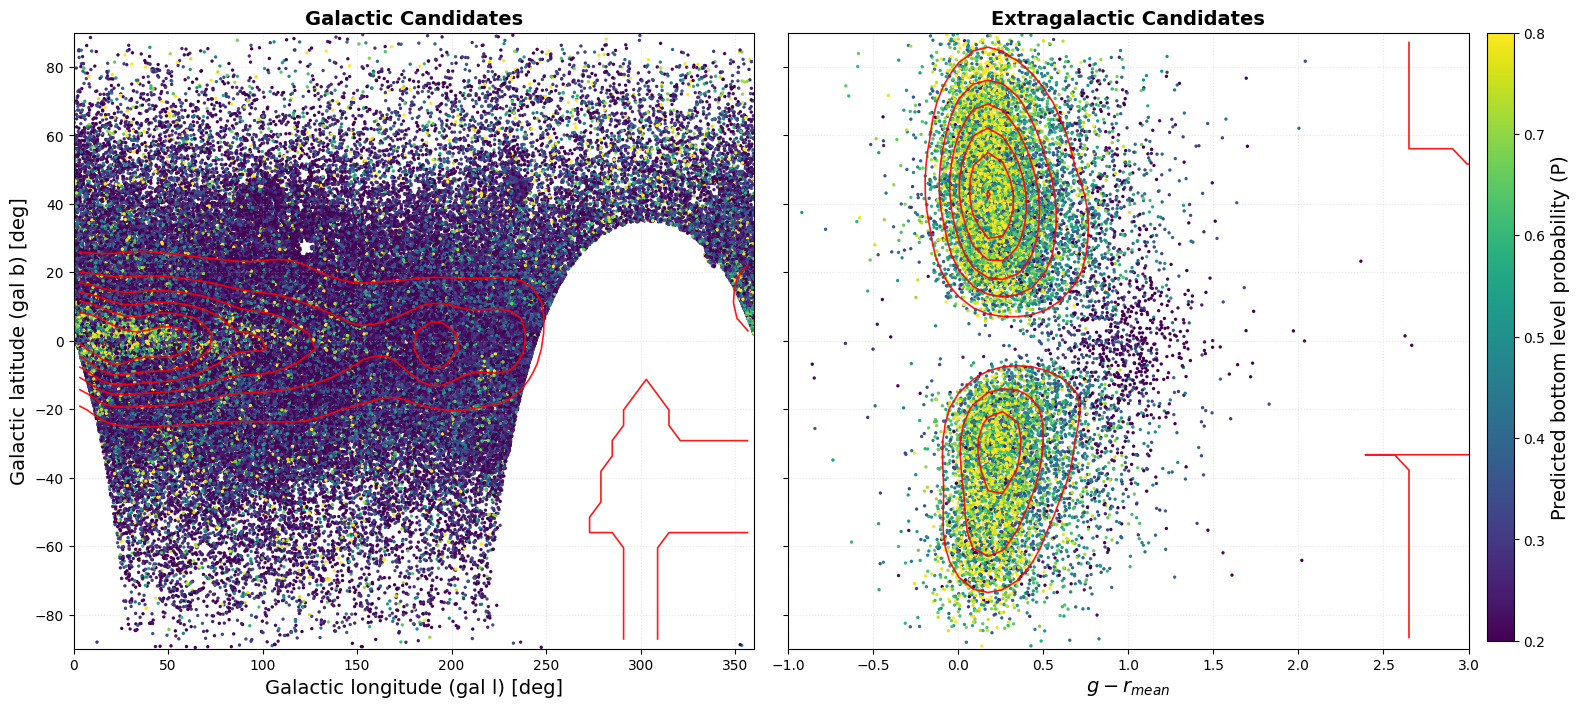

In [18]:
# --- EJECUCIÓN ---
# Asegúrate de que df_features y probs existen en tu entorno
full_df = prepare_data(df_features, prob_squid_wide_bottom)
plot_figure_17_updated(full_df)

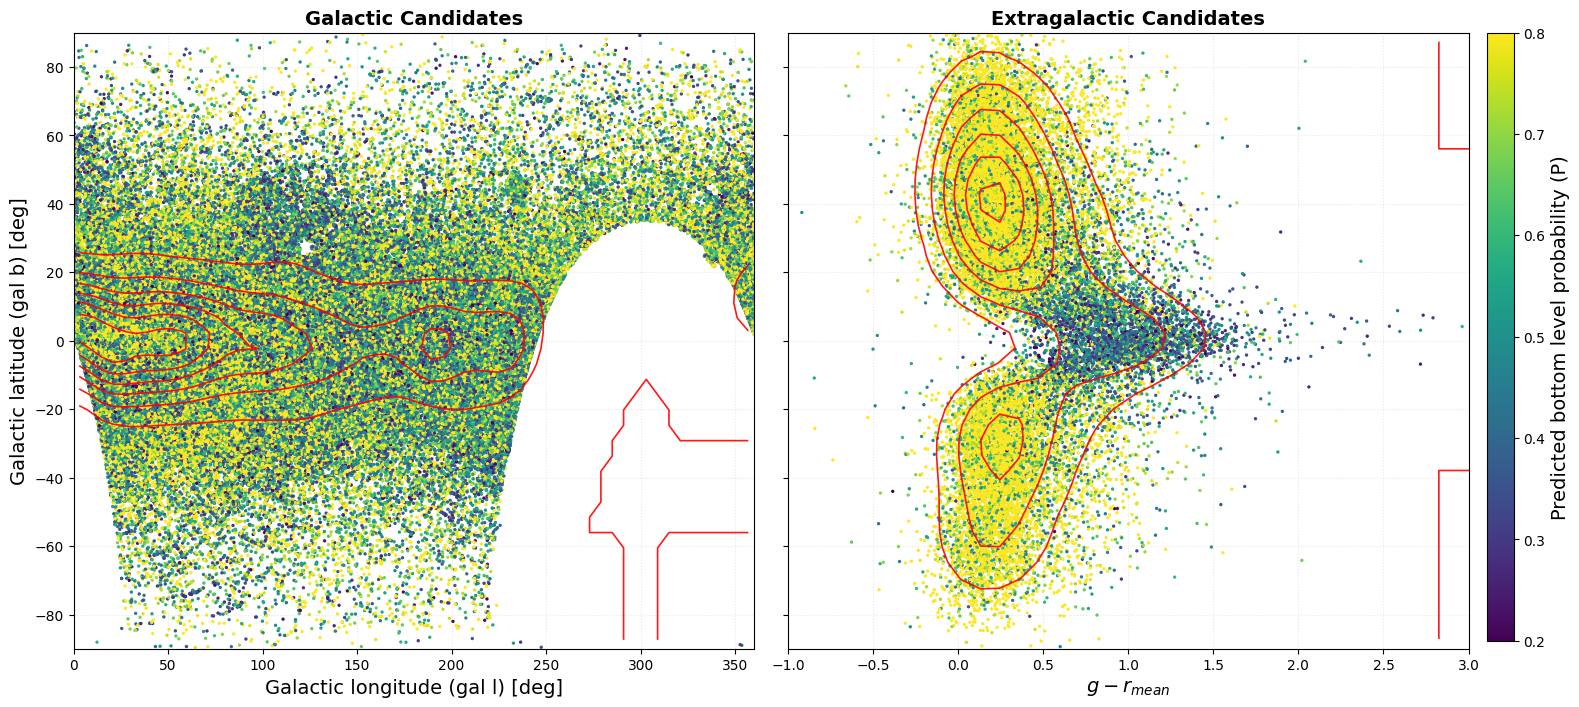

In [19]:
full_df = prepare_data(df_features, prob_mbappe_wide_bottom)
plot_figure_17_updated(full_df)